In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.datasets import co2, get_rdataset

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = [12, 5] 

In [2]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch9')
price = pd.read_csv(path / 'closing_price.csv')
price.head()

,Date,AAPL,MSFT,IBM
0,2019-11-01,62.830273,140.552994,115.847458
1,2019-11-04,63.242901,141.364731,117.676682
2,2019-11-05,63.152027,141.276733,117.864746
3,2019-11-06,63.179031,140.885513,118.625488
4,2019-11-07,63.908203,141.081116,119.083855


In [3]:
co2 = co2.load_pandas().data
co2 = co2.ffill()
co2.head()

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


In [4]:
air_passengers = get_rdataset("AirPassengers")
air_df = air_passengers.data
air_df.index = pd.date_range('1949','1961', freq='M')
air_df.drop(columns=['time'], inplace=True)
air_df.head()

/tmp/ipykernel_5791/2801627828.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  air_df.index = pd.date_range('1949','1961', freq='M')


,value
1949-01-31,112
1949-02-28,118
1949-03-31,132
1949-04-30,129
1949-05-31,121


<Axes: >

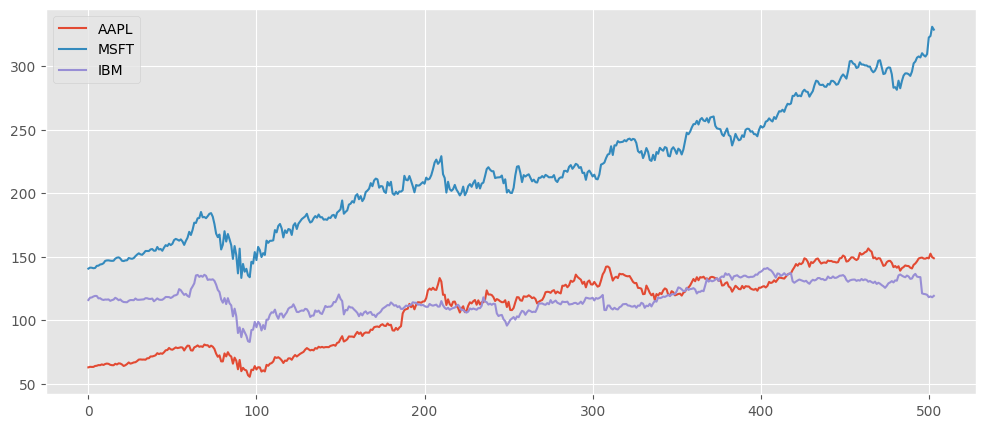

In [5]:
price.plot()

<Axes: >

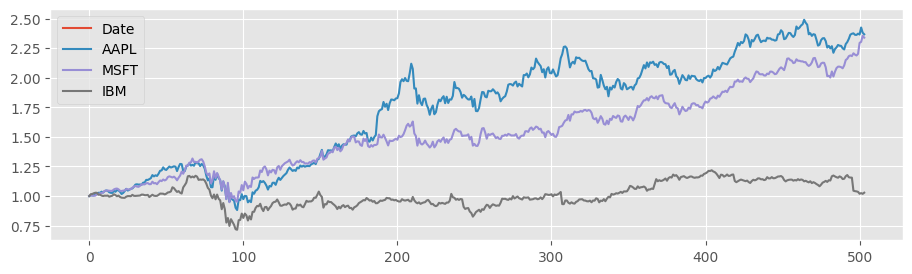

In [6]:
price = pd.DataFrame(price)

price = price.apply(pd.to_numeric, errors='coerce')

price_n = price.div(price.iloc[0])
price_n.plot(figsize=(11,3))

In [7]:
price_n.head()

,Date,AAPL,MSFT,IBM
0,NaN,1.000000,1.000000,1.000000
1,NaN,1.006567,1.005775,1.015790
2,NaN,1.005121,1.005149,1.017413
3,NaN,1.005551,1.002366,1.023980
4,NaN,1.017156,1.003757,1.027937


<Axes: >

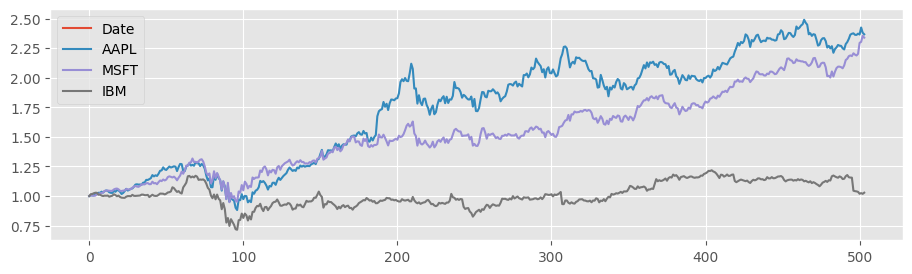

In [8]:
plt.style.use('ggplot')
price_n.plot(figsize=(11,3))

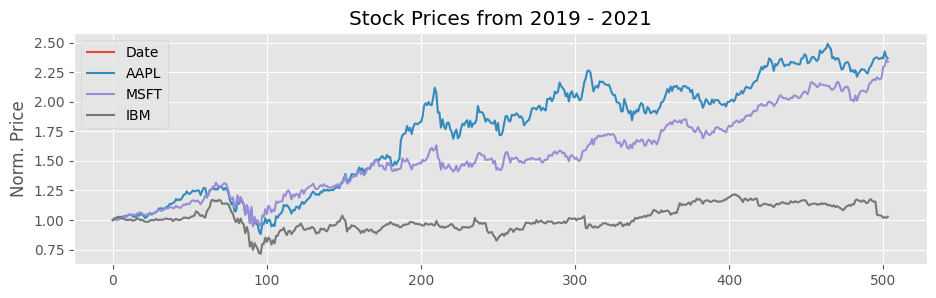

In [9]:
start_date = '2019'
end_date = '2021'

plot = price_n.plot(figsize=(11,3),
title=f'Stock Prices from {start_date} - {end_date}',
ylabel= 'Norm. Price')
plot.get_figure().savefig('plot_1.jpg')